In [208]:
import pandas as pd
import duckdb
con = duckdb.connect()
pd.options.display.float_format = '{:,.3f}'.format


In [209]:
# Số lượng sản phẩm theo danh mục và phân khúc
query_num_product = """
    SELECT category, segment, COUNT(*) as num_product,
        AVG(price-cogs) as avg_profit,
        MIN(price-cogs) as min_profit,
        MAX(price - cogs) as max_profit
    FROM '../../../data/master/products.csv'
    GROUP BY category, segment
""" 
df_num_product = con.execute(query_num_product).df()
df_num_product

,category,segment,num_product,avg_profit,min_profit,max_profit
0,Outdoor,Premium,177,459.423,5.563,"3,043.454"
1,Streetwear,Performance,347,"1,477.745",4.732,"13,118.385"
2,Outdoor,Activewear,566,537.476,4.369,"2,687.928"
3,Streetwear,Balanced,306,"1,999.432",7.234,"9,450.121"
4,Casual,All-weather,169,856.224,6.070,"4,006.724"
5,GenZ,Trendy,148,467.458,6.557,"2,525.662"
6,Streetwear,Everyday,405,"1,541.690",6.253,"7,918.036"
7,Casual,Activewear,32,"1,020.823",8.846,"2,772.204"
8,Streetwear,Standard,262,669.221,3.873,"4,056.233"


In [210]:
query_product = """
    SELECT * 
    FROM '../../../data/master/products.csv'
""" 
df_product = con.execute(query_product).df()
df_product

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.650","9,704.843"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.076","5,393.870"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.633","11,371.919"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.717","8,573.173"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.335","14,063.570"
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,"4,603.340","2,553.933"
2408,1261,VietMode MP-29,Casual,Activewear,M,black,"5,983.876","4,653.661"
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,"5,983.876","5,684.683"
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,"5,984.370","5,685.151"


Tổng có 2412 sản phẩm (product_id) được chia thành 8 segment

In [211]:
num_product = df_num_product.groupby("category")["num_product"].sum().sort_values(ascending=False)
num_product

category
Streetwear    1320
Outdoor        743
Casual         201
GenZ           148
Name: num_product, dtype: int64

Hầu như các sản phẩm là Streetwear. Số lượng sản phẩm là tính theo product_id 

<Axes: title={'center': 'Số lượng sản phẩm theo danh mục'}>

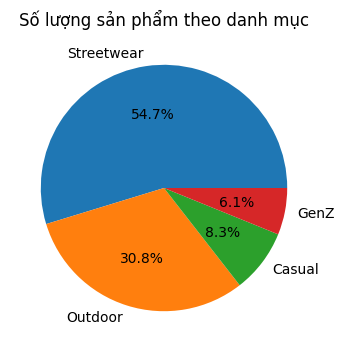

In [212]:
num_product.plot(kind="pie", autopct='%1.1f%%', figsize=(4, 4), title="Số lượng sản phẩm theo danh mục")

In [213]:
query_sell_product = """
SELECT 
    p.product_id,
    p.product_name,
    p.category,
    p.segment,

    SUM(oi.quantity) AS total_quantity,
    SUM(oi.quantity * oi.unit_price) AS revenue,
    SUM(oi.quantity * p.cogs) AS cost,
    SUM(oi.quantity * oi.unit_price) - SUM(oi.quantity * p.cogs) AS profit

FROM '../../../data/transaction/order_items.csv' oi
JOIN '../../../data/master/products.csv' p
ON oi.product_id = p.product_id

GROUP BY 
    p.product_id, p.product_name, p.category, p.segment
ORDER BY total_quantity DESC
"""
df_sell_product = con.execute(query_sell_product).df()
df_sell_product

,product_id,product_name,category,segment,total_quantity,revenue,cost,profit
0,791,HanoiStreet RP-79,Outdoor,Activewear,"45,986.000","33,999,756.290","26,900,165.224","7,099,591.066"
1,792,HanoiStreet RP-80,Outdoor,Activewear,"45,726.000","33,817,877.490","29,688,320.883","4,129,556.607"
2,604,SaigonFlex UC-69,Streetwear,Everyday,"36,515.000","207,930,650.930","151,242,947.884","56,687,703.046"
3,2045,UrbanVN UE-05,Streetwear,Performance,"35,844.000","185,081,235.240","107,401,912.240","77,679,323.000"
4,487,SaigonFlex UM-92,Streetwear,Balanced,"33,277.000","398,213,557.450","366,971,097.506","31,242,459.944"
...,...,...,...,...,...,...,...,...
1593,1447,VietMode RP-39,Outdoor,Activewear,1.000,"1,391.980","1,614.753",-222.773
1594,1615,VietMode RS-53,Outdoor,Premium,1.000,"2,519.940","3,009.504",-489.564
1595,5,DragonWear MA-05,Casual,All-weather,1.000,"7,673.590","8,498.700",-825.110
1596,1385,VietMode RP-77,Outdoor,Activewear,1.000,"3,790.330","2,845.289",945.041


Có 2412 sản phẩm (product_id) nhưng trước giờ chỉ chỉ bán được 1598 sản phẩm, tức là có 814 sản phẩm chưa từng được bán ra

`=> Cần xem lại chiến lược marketing cho các sản phẩm chưa từng được bán ra, hoặc xem lại chất lượng của các sản phẩm đó.`

In [214]:
df_sell_product["margin"] = df_sell_product["profit"] * 1.0 / df_sell_product["revenue"]
df_sell_product

,product_id,product_name,category,segment,total_quantity,revenue,cost,profit,margin
0,791,HanoiStreet RP-79,Outdoor,Activewear,"45,986.000","33,999,756.290","26,900,165.224","7,099,591.066",0.209
1,792,HanoiStreet RP-80,Outdoor,Activewear,"45,726.000","33,817,877.490","29,688,320.883","4,129,556.607",0.122
2,604,SaigonFlex UC-69,Streetwear,Everyday,"36,515.000","207,930,650.930","151,242,947.884","56,687,703.046",0.273
3,2045,UrbanVN UE-05,Streetwear,Performance,"35,844.000","185,081,235.240","107,401,912.240","77,679,323.000",0.420
4,487,SaigonFlex UM-92,Streetwear,Balanced,"33,277.000","398,213,557.450","366,971,097.506","31,242,459.944",0.078
...,...,...,...,...,...,...,...,...,...
1593,1447,VietMode RP-39,Outdoor,Activewear,1.000,"1,391.980","1,614.753",-222.773,-0.160
1594,1615,VietMode RS-53,Outdoor,Premium,1.000,"2,519.940","3,009.504",-489.564,-0.194
1595,5,DragonWear MA-05,Casual,All-weather,1.000,"7,673.590","8,498.700",-825.110,-0.108
1596,1385,VietMode RP-77,Outdoor,Activewear,1.000,"3,790.330","2,845.289",945.041,0.249


In [215]:
cat_revenue = df_sell_product.groupby("category")["revenue"].sum().sort_values(ascending=False)
print(cat_revenue)

category
Streetwear   13,131,346,352.620
Outdoor       2,494,882,754.200
Casual          460,648,383.350
GenZ            343,599,095.360
Name: revenue, dtype: float64


<Axes: title={'center': 'Revenue by Category'}, xlabel='category'>

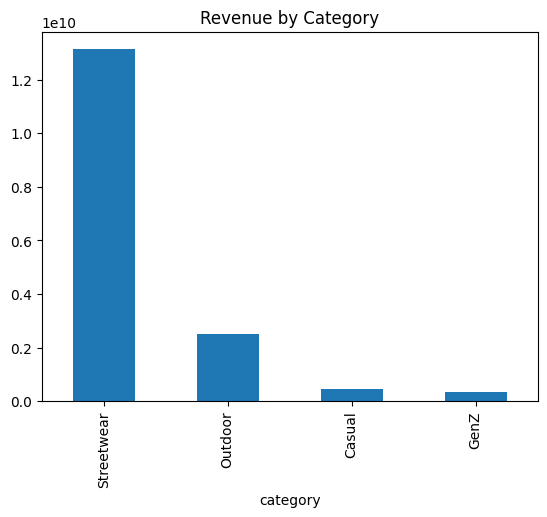

In [216]:
cat_revenue.plot(kind="bar", title="Revenue by Category")

<Axes: title={'center': 'Doanh thu theo danh mục'}>

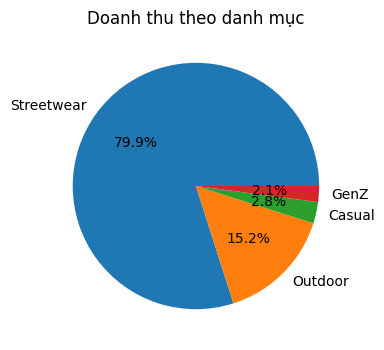

In [217]:
cat_revenue.plot(kind="pie", autopct='%1.1f%%', figsize=(4, 4), title="Doanh thu theo danh mục")

Bị concentration - Streetwear dominate doanh thu, chiếm 80% tổng doanh thu. Các segment còn lại chiếm 20% tổng doanh thu.

### Category nào có margin cao nhất

In [218]:
cat_margin = df_sell_product.groupby("category")["margin"].mean().sort_values(ascending=False)
print(cat_margin)

category
Casual       0.180
Outdoor      0.162
GenZ         0.159
Streetwear   0.155
Name: margin, dtype: float64


<Axes: title={'center': 'Mean Margin by Category'}, xlabel='category'>

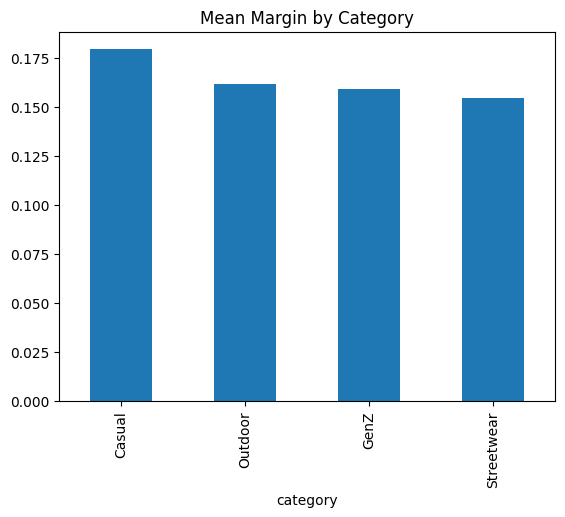

In [219]:
cat_margin.plot(kind="bar", title="Mean Margin by Category")

### Trung bình profit theo category

In [220]:
df_sell_product['avg_profit'] = df_sell_product['profit'] / df_sell_product['total_quantity']
cat_profit = df_sell_product.groupby("category")["avg_profit"].mean().sort_values(ascending=False)
print(cat_profit)

category
Streetwear   1,276.262
Casual       1,018.121
Outdoor        516.125
GenZ           406.087
Name: avg_profit, dtype: float64


<Axes: title={'center': 'Average Profit by Category'}, xlabel='category'>

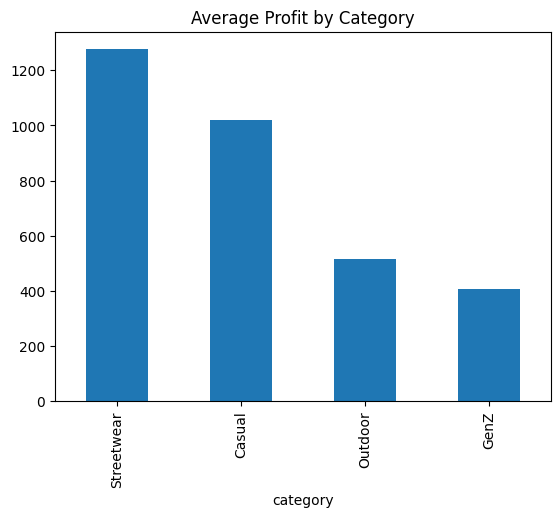

In [221]:
cat_profit.plot(kind="bar",title="Average Profit by Category")

### Sản phẩm bán được nhiều nhưng không kiếm được tiền

In [222]:
high_volume = df_sell_product[df_sell_product["total_quantity"] > df_sell_product["total_quantity"].quantile(0.75)]
low_profit = high_volume.sort_values("profit").head(20)

print(low_profit[["product_name", "total_quantity", "profit"]])

          product_name  total_quantity         profit
9    HanoiStreet UM-10      28,993.000 -8,373,024.658
8    HanoiStreet UE-36      31,220.000 -5,507,566.812
10    SaigonFlex UM-96      24,485.000 -5,449,372.010
50    SaigonFlex UM-11      14,249.000 -4,260,019.241
118   SaigonFlex UM-12       7,290.000 -4,061,755.442
60    SaigonFlex UM-01      12,749.000 -4,039,363.298
21       UrbanVN UE-15      21,054.000 -4,039,130.021
11       UrbanVN UE-14      24,418.000 -3,957,637.957
51    SaigonFlex UC-16      14,246.000 -3,366,691.461
25   HanoiStreet UE-16      20,192.000 -2,998,262.456
130   SaigonFlex UC-64       6,734.000 -2,267,679.255
232   SaigonFlex UM-66       3,575.000 -2,082,298.099
94    SaigonFlex UC-22       8,570.000 -1,847,708.079
138   SaigonFlex UC-45       6,470.000 -1,809,143.397
40   HanoiStreet UC-39      15,557.000 -1,660,573.733
110   SaigonFlex UM-37       7,910.000 -1,652,244.086
150   VietMotion UC-24       6,056.000 -1,529,188.507
247   SaigonFlex UM-77      

### Sản phẩm lợi nhuận cao nhưng bán ít

In [223]:
low_volume = df_sell_product[df_sell_product["total_quantity"] < df_sell_product["total_quantity"].quantile(0.25)]
high_profit = low_volume.sort_values("profit", ascending=False).head(20)

print(high_profit[["product_name", "total_quantity", "profit"]])

           product_name  total_quantity      profit
1214    LotusWear UE-02          83.000 459,986.403
1232    LotusWear UE-45          75.000 381,105.862
1219   SaigonFlex UC-03          82.000 305,318.509
1240   SaigonFlex UM-89          72.000 274,378.894
1258    LotusWear UM-01          67.000 273,826.235
1297    LotusWear UE-93          53.000 269,335.850
1243   SaigonFlex UM-57          72.000 265,489.943
1207   DragonWear UE-10          86.000 258,040.286
1226     VietMode MA-14          77.000 216,416.709
1348    LotusWear UE-74          37.000 203,668.711
1215     VietMode UR-01          83.000 196,304.567
1314   SaigonCore UE-02          46.000 187,327.882
1223  PhoenixWear UR-07          79.000 186,864.380
1233   SaigonFlex UM-22          75.000 185,556.843
1268  BambooCraft UC-10          63.000 178,808.790
1276   SaigonCore MA-05          60.000 178,257.482
1311  BambooCraft UM-02          46.000 176,367.178
1331  PhoenixWear UE-07          40.000 174,220.698
1278    Lotu

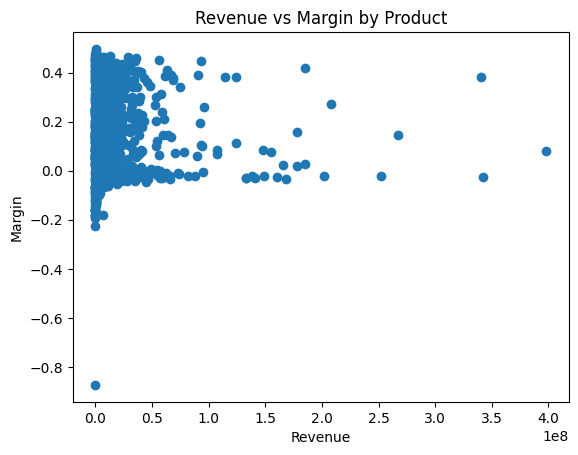

In [224]:
import matplotlib.pyplot as plt

plt.scatter(df_sell_product["revenue"], df_sell_product["margin"])
plt.xlabel("Revenue")
plt.ylabel("Margin")
plt.title("Revenue vs Margin by Product")
plt.show()
#scatter plot revenue vs margin, color by category 

In [225]:
query = """ 
    SELECT COUNT(*) AS num_order
    FROM '../../../data/transaction/order_items.csv' oi
"""
df_num_order = con.execute(query).df()
df_num_order

,num_order
0,714669


In [226]:
query = """ 
    SELECT * FROM '../../../data/operational/inventory.csv'
    WhERE product_id = '5'
"""
df_inventory = con.execute(query).df()
df_inventory

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2013-02-28,5,3,1,1,1,90.000,0.967,1,0,0,0.250,DragonWear MA-05,Casual,All-weather,2013,2
1,2013-03-31,5,3,1,1,2,90.000,0.933,1,0,0,0.250,DragonWear MA-05,Casual,All-weather,2013,3


In [227]:
query = """ 
SELECT * FROM '../../../data/transaction/returns.csv'
WHERE product_id = '5'
"""
df_return = con.execute(query).df()
df_return

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount


In [228]:
query=""" 
    SELECT * FROM '../../../data/operational/inventory.csv'
    WHERE YEAR(snapshot_date) = 2012 and product_id = 609
"""
df_inventory_2012 = con.execute(query).df()
df_inventory_2012

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2012-07-31,609,236,92,72,2,98.300,0.933,1,1,0,0.234,SaigonFlex UC-74,Streetwear,Everyday,2012,7
1,2012-08-31,609,244,65,57,1,128.400,0.967,1,1,0,0.189,SaigonFlex UC-74,Streetwear,Everyday,2012,8
2,2012-09-30,609,250,51,45,1,166.700,0.967,1,1,0,0.152,SaigonFlex UC-74,Streetwear,Everyday,2012,9
3,2012-10-31,609,255,48,43,0,177.900,1.000,0,1,0,0.144,SaigonFlex UC-74,Streetwear,Everyday,2012,10
4,2012-11-30,609,260,50,45,1,173.300,0.967,1,1,0,0.147,SaigonFlex UC-74,Streetwear,Everyday,2012,11
5,2012-12-31,609,267,40,33,1,242.700,0.967,1,1,0,0.110,SaigonFlex UC-74,Streetwear,Everyday,2012,12


In [229]:
query = """ 
SELECT * FROM '../../../data/transaction/order_items.csv'

WHERE product_id = '609' 
"""
df_order_items_609 = con.execute(query).df()
df_order_items_609.head(20)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,2,609,7,"10,166.250",0.000,NaN,NaN
1,26,609,2,"10,196.640",0.000,NaN,NaN
2,172,609,3,"10,263.170",0.000,NaN,NaN
3,217,609,6,"10,625.380",0.000,NaN,NaN
4,224,609,4,"10,478.060",0.000,NaN,NaN
5,233,609,7,"10,421.740",0.000,NaN,NaN
6,245,609,5,"10,304.670",0.000,NaN,NaN
7,268,609,1,"10,404.920",0.000,NaN,NaN
8,275,609,2,"10,461.990",0.000,NaN,NaN
9,353,609,1,"10,302.240",0.000,NaN,NaN


## Sản phẩm bị trùng lặp

In [230]:
df_product = pd.read_csv('../../../data/master/products.csv')
df_product 

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.650","9,704.843"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.076","5,393.870"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.633","11,371.919"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.717","8,573.173"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.335","14,063.570"
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,"4,603.340","2,553.933"
2408,1261,VietMode MP-29,Casual,Activewear,M,black,"5,983.876","4,653.661"
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,"5,983.876","5,684.683"
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,"5,984.370","5,685.151"


In [231]:
df_product['product_name'].unique()

<StringArray>
['SaigonFlex UC-01', 'SaigonFlex UC-02', 'SaigonFlex UC-03',
 'SaigonFlex UC-04', 'SaigonFlex UC-05', 'SaigonFlex UC-06',
 'SaigonFlex UC-07', 'SaigonFlex UC-08', 'SaigonFlex UC-09',
 'SaigonFlex UC-10',
 ...
   'VietMode MP-23',   'VietMode MP-24',   'VietMode MP-25',
   'VietMode MP-26',   'VietMode MP-27',   'VietMode MP-28',
   'VietMode MP-29',   'VietMode MP-30',   'VietMode MP-31',
   'VietMode MP-32']
Length: 2172, dtype: str

In [232]:
# Kiểm tra product_name xuất hiện nhiều hơn 1 lần
duplicated_products = df_product['product_name'].value_counts()
duplicated_products = duplicated_products[duplicated_products > 1]
duplicated_products

product_name
VietMode RP-01    3
VietMode RP-02    3
VietMode RP-03    3
VietMode RP-04    3
VietMode RP-05    3
                 ..
VietMode RP-96    2
VietMode RP-97    2
VietMode RP-98    2
VietMode RP-99    2
VietMode RP-00    2
Name: count, Length: 186, dtype: int64

Có 186 product_name xuất hiên 2-3 lần; 1986 product_name xuất hiện 1 lần.

In [233]:
df_dup_name = df_product.loc[df_product['product_name'].isin(duplicated_products.index)].sort_values(by='product_name')
df_dup_name.to_csv('../../../data/processed/duplicated_product_names.csv', index=False)

In [234]:
df_dup_name 

,product_id,product_name,category,segment,size,color,price,cogs
745,380,LotusWear UE-01,Streetwear,Performance,S,red,34.036,21.344
645,280,LotusWear UE-01,Streetwear,Performance,S,red,"12,596.850","11,967.007"
646,281,LotusWear UE-02,Streetwear,Performance,M,black,"15,746.850","8,750.525"
746,381,LotusWear UE-02,Streetwear,Performance,M,black,21.652,12.139
647,282,LotusWear UE-03,Streetwear,Performance,L,orange,"14,486.850","12,008.150"
...,...,...,...,...,...,...,...,...
1767,1665,VietMode RS-03,Outdoor,Premium,M,purple,24.470,15.844
1668,1566,VietMode RS-04,Outdoor,Premium,L,green,"4,467.960","3,904.103"
1768,1666,VietMode RS-04,Outdoor,Premium,L,green,"2,847.543","2,029.159"
1669,1567,VietMode RS-05,Outdoor,Premium,XL,silver,"4,999.050","4,046.231"


### Lấy sản phẩm giá thấp nhất trong mỗi nhóm trùng lặp 


In [235]:
df_min = df_dup_name.loc[df_dup_name.groupby("product_name")["price"].idxmin()].sort_values(by='product_id').copy()
df_min

,product_id,product_name,category,segment,size,color,price,cogs
648,283,LotusWear UE-04,Streetwear,Performance,XL,blue,24.025,15.411
649,284,LotusWear UE-05,Streetwear,Performance,S,white,31.046,18.376
650,285,LotusWear UE-06,Streetwear,Performance,M,purple,38.924,22.900
651,286,LotusWear UE-07,Streetwear,Performance,L,green,70.420,42.385
745,380,LotusWear UE-01,Streetwear,Performance,S,red,34.036,21.344
...,...,...,...,...,...,...,...,...
1765,1663,VietMode RS-01,Outdoor,Premium,XL,blue,17.417,9.977
1766,1664,VietMode RS-02,Outdoor,Premium,S,white,35.923,23.337
1767,1665,VietMode RS-03,Outdoor,Premium,M,purple,24.470,15.844
1768,1666,VietMode RS-04,Outdoor,Premium,L,green,"2,847.543","2,029.159"


In [236]:
df_min.loc[df_min['price'] < 1000]

,product_id,product_name,category,segment,size,color,price,cogs
648,283,LotusWear UE-04,Streetwear,Performance,XL,blue,24.025,15.411
649,284,LotusWear UE-05,Streetwear,Performance,S,white,31.046,18.376
650,285,LotusWear UE-06,Streetwear,Performance,M,purple,38.924,22.900
651,286,LotusWear UE-07,Streetwear,Performance,L,green,70.420,42.385
745,380,LotusWear UE-01,Streetwear,Performance,S,red,34.036,21.344
...,...,...,...,...,...,...,...,...
2370,1553,VietMode RP-45,Outdoor,Activewear,M,blue,11.260,6.890
2371,1554,VietMode RP-46,Outdoor,Activewear,L,white,32.404,19.324
1765,1663,VietMode RS-01,Outdoor,Premium,XL,blue,17.417,9.977
1766,1664,VietMode RS-02,Outdoor,Premium,S,white,35.923,23.337


Trong 186 sản phẩm bị lặp lại, 67 sản phẩm < 100đ, 2 sản phẩm 900-1000đ, 10 sản phẩm 1000-2000đ

### Lấy sản phẩm giá cao nhất trong mỗi nhóm trùng lặp

In [237]:
df_max = df_dup_name.loc[df_dup_name.groupby("product_name")["price"].idxmax()].sort_values(by='product_id').copy()
df_max

,product_id,product_name,category,segment,size,color,price,cogs
645,280,LotusWear UE-01,Streetwear,Performance,S,red,"12,596.850","11,967.007"
646,281,LotusWear UE-02,Streetwear,Performance,M,black,"15,746.850","8,750.525"
647,282,LotusWear UE-03,Streetwear,Performance,L,orange,"14,486.850","12,008.150"
748,383,LotusWear UE-04,Streetwear,Performance,XL,blue,"7,286.850","6,664.553"
749,384,LotusWear UE-05,Streetwear,Performance,S,white,"12,596.850","10,771.566"
...,...,...,...,...,...,...,...,...
1665,1563,VietMode RS-01,Outdoor,Premium,XL,blue,"3,463.740","3,132.260"
1666,1564,VietMode RS-02,Outdoor,Premium,S,white,"4,112.820","3,718.401"
1667,1565,VietMode RS-03,Outdoor,Premium,M,purple,"3,747.240","2,006.272"
1668,1566,VietMode RS-04,Outdoor,Premium,L,green,"4,467.960","3,904.103"


In [238]:
df_order_items = pd.read_csv('../../../data/transaction/order_items.csv')
df_order = pd.read_csv('../../../data/transaction/orders.csv')
df_product = pd.read_csv('../../../data/master/products.csv')

C:\Users\LE HOANG THAO ANH\AppData\Local\Temp\ipykernel_18940\4199414024.py:1: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../../../data/transaction/order_items.csv')


In [239]:
df_order_items.count()

order_id           714669
product_id         714669
quantity           714669
unit_price         714669
discount_amount    714669
promo_id           276316
promo_id_2            206
dtype: int64

Trong order_items có 714669 rows 

In [240]:
df_order_items_dup = df_order_items.loc[df_order_items['product_id'].isin(df_min['product_id'])].copy()
df_order_items_dup.sort_values(by='product_id')

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
129111,145763,382,7,"11,324.590",0.000,NaN,NaN
124015,140255,382,4,"8,499.530","6,799.620",PROMO-0004,NaN
102573,116774,382,7,"10,114.170","7,079.920",PROMO-0003,NaN
100465,114298,382,7,"10,023.910","7,016.740",PROMO-0003,NaN
90910,103277,382,4,"5,443.060",200.000,PROMO-0005,NaN
...,...,...,...,...,...,...,...
587319,680359,1667,4,"4,403.490",0.000,NaN,NaN
665574,774623,1667,3,"4,408.280",0.000,NaN,NaN
599331,694700,1667,2,"3,375.350","1,350.140",PROMO-0034,NaN
697617,813553,1667,7,"3,715.120","4,681.050",PROMO-0048,NaN


Trong 714669 rows, có 51689 rows mua được product mà bị trùng lặp mà có giá thấp nhất

In [241]:
a =df_order_items_dup.loc[df_order_items_dup['unit_price'] < 1000]
a

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
24,29,1484,2,950.750,0.000,NaN,NaN
626,792,1484,4,997.690,0.000,NaN,NaN
2045,2470,1484,8,965.320,0.000,NaN,NaN
5624,6633,1483,3,967.020,0.000,NaN,NaN
5625,6633,1484,5,969.880,0.000,NaN,NaN
...,...,...,...,...,...,...,...
480845,553231,1484,7,798.830,"1,118.360",PROMO-0024,NaN
482776,555209,1483,7,798.560,"1,117.980",PROMO-0024,NaN
486541,559633,1483,7,963.150,0.000,NaN,NaN
486542,559633,1484,4,995.950,0.000,NaN,NaN


In [242]:
a['product_id'].nunique()

2

Trong 69 sản phẩm có 0 đồng, thì người ta chỉ mua được 2 sản phẩm 

Trong những product_name xuất hiện nhiều lần, có những product giảm giá sâu, có những product không chênh giá thường nhiều

Xét mã rẻ nhất theo từng loại sản phẩm:

Có 51689 lượt mua được mã sản phẩm rẻ nhất, nhưng chỉ 662 lượt mua những sản phẩm được giá giảm sâu 0đ (đang để là < 1000), và 662 lượt mua đó chỉ nằm trong 2 sản phẩm

Có 42712 lượt mua sản phẩm với giá cao nhất 